# Customer Segmentation & Revenue Analytics

**Author:** Dilly Nguyen

## Business Problem

Analyze over one million retail transactions to identify customer purchasing behavior, revenue trends, and customer segments that can support targeted marketing strategies and improve customer retention.

## Project Workflow

1. Data Profiling
2. Data Cleaning
3. Exploratory Data Analysis
4. Customer Segmentation (RFM)
5. Business Insights
6. Tableau Dashboard
7. Recommendations

In [4]:
# Load Excel workbook
excel_file = pd.ExcelFile("online_retail_II.xlsx")

# Display worksheet names
print("Worksheets:")
print(excel_file.sheet_names)

# Read both worksheets
df1 = pd.read_excel(
    "online_retail_II.xlsx",
    sheet_name="Year 2009-2010"
)

df2 = pd.read_excel(
    "online_retail_II.xlsx",
    sheet_name="Year 2010-2011"
)

# Combine into one DataFrame
df = pd.concat([df1, df2], ignore_index=True)

Worksheets:
['Year 2009-2010', 'Year 2010-2011']


## Phase 1: Data Profiling
### Business Question: What does our dataset look like, and are there any data quality issues before analysis?

In [2]:
## Dataset size
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 1,067,371
Columns: 8


In [13]:
## Dataset structure
from IPython.display import display
display(df.columns)
df.info()
df.head(10)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [9]:
## Missing Values
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [10]:
## Duplicate Records
df.duplicated().sum()

np.int64(34335)

In [11]:
## Summary Statistics
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


## Phase 1 Summary
Key findings:
- Dataset contains over one million retail transactions.
- Customer ID has missing values.
- Description has a small number of missing values.
- Duplicate records exist.
- Negative quantities and prices require further investigation.

## Phase 2: Data Quality Assessment & Cleaning
### Business Question: Which records should be retained or removed to ensure accurate business analysis and customer segmentation?

## Missing Customer IDs

In [15]:
missing_customerID = df[df["Customer ID"].isnull()]
print("Transactions without Customer ID:")
print(len(missing_customerID))
missing_customerID.head(10)

Transactions without Customer ID:
243007


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


### Observation
There are **243,007 transactions** with missing Customer IDs.
The sample shows that these transactions include a mix of:
- anonymous purchases,
- returned items (negative quantities),
- and zero-priced records.
Because customer-level analyses such as RFM segmentation require a unique customer identifier, these records will be excluded during the customer analytics stage.

## Missing Product Descriptions

In [16]:
missing_description = df[df["Description"].isnull()]
print("Transactions without Description:")
print(len(missing_description))
missing_description.head(10)

Transactions without Description:
4382


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom
6378,489882,35751C,NaN,12,2009-12-02 16:22:00,0.0,NaN,United Kingdom
6555,489898,79323G,NaN,954,2009-12-03 09:40:00,0.0,NaN,United Kingdom
6576,489901,21098,NaN,-200,2009-12-03 09:47:00,0.0,NaN,United Kingdom
6581,489903,21166,NaN,48,2009-12-03 09:57:00,0.0,NaN,United Kingdom


In [17]:
### Question: Are all missing descriptions priced at zero?
missing_description["Price"].value_counts()

Price
0.0    4382
Name: count, dtype: int64

In [18]:
### Question: Are all missing descriptions also missing Customer IDs?
missing_description["Customer ID"].isnull().sum()

np.int64(4382)

In [19]:
### Question: How many have negative quantities?
(missing_description["Quantity"] < 0).sum()

np.int64(2689)

### Observation
A total of **4,382 transactions** have missing product descriptions.
Further investigation revealed that:
- **100%** have a unit price of **£0.00**
- **100%** have missing Customer IDs
- Approximately **61%** (2,689 transactions) have negative quantities
These records do not exhibit the characteristics of normal customer purchases and are likely inventory adjustments, administrative entries, or internal system transactions. Therefore, they will be excluded from subsequent sales and customer analyses.

## Negative Quantities

In [20]:
negative_quantity = df[df["Quantity"] < 0]
print(f"Transactions with negative quantities: {len(negative_quantity):,}")
negative_quantity.head(15)

Transactions with negative quantities: 22,950


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


### Test hypothesis

In [21]:
#### Do all negative quantities start with "C"?
negative_quantity["Invoice"].astype(str).str.startswith("C").value_counts()

Invoice
True     19493
False     3457
Name: count, dtype: int64

In [22]:
#### How many unique cancelled invoices?
negative_quantity["Invoice"].nunique()

11684

In [23]:
#### Are all prices positive?
negative_quantity["Price"].describe()

count    22950.000000
mean        38.098715
std        549.831443
min          0.000000
25%          0.850000
50%          2.250000
75%          4.950000
max      38970.000000
Name: Price, dtype: float64

In [26]:
#### Based on these three question, here's the important question to answer: What are those 3,457 negative-quantity records that do NOT start with "C"?
negative_not_c = negative_quantity[
    ~negative_quantity["Invoice"].astype(str).str.startswith("C")
]
print(f"Negative quantities without 'C' invoice: {len(negative_not_c):,}")
negative_not_c.head(20)

Negative quantities without 'C' invoice: 3,457


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom
4538,489820,21133,invcd as 84879?,-720,2009-12-02 13:23:00,0.0,NaN,United Kingdom
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom


In [28]:
##### How many of these have Price = 0?
negative_not_c["Price"].value_counts().head(10)

Price
0.0    3457
Name: count, dtype: int64

In [27]:
##### Are these mostly missing Customer IDs?
negative_not_c["Customer ID"].isnull().value_counts()

Customer ID
True    3457
Name: count, dtype: int64

### Observation
The dataset contains **22,950 transactions** with negative quantities.
Further investigation identified two distinct categories:
1. **Customer Returns / Cancellations (19,493 transactions)**
   - Invoice numbers begin with **"C"**
   - Valid Customer IDs
   - Valid product descriptions
   - Positive unit prices
2. **Inventory Adjustment Records (3,457 transactions)**
   - Invoice numbers do **not** begin with **"C"**
   - All have **Price = 0**
   - All have missing **Customer IDs**
   - Many contain operational descriptions such as *lost* or *damages*
These records represent operational inventory activities rather than completed customer purchases.
Both categories will be excluded from analyses focused on sales performance and customer behavior.

In [30]:
df_clean = df.copy()
## Remove duplicates
print(f"Rows before removing duplicates: {len(df_clean):,}")
df_clean = df_clean.drop_duplicates()
print(f"Rows after removing duplicates: {len(df_clean):,}")

## Remove missing descriptions
print(f"Rows before removing missing descriptions: {len(df_clean):,}")
df_clean = df_clean.dropna(subset=["Description"])
print(f"Rows after removing missing descriptions: {len(df_clean):,}")

## Remove missing Customer IDs
print(f"Rows before removing missing Customer IDs: {len(df_clean):,}")
df_clean = df_clean.dropna(subset=["Customer ID"])
print(f"Rows after removing missing Customer IDs: {len(df_clean):,}")

## Remove cancelled invoices
print(f"Rows before removing cancelled invoices: {len(df_clean):,}")
df_clean = df_clean[
    ~df_clean["Invoice"].astype(str).str.startswith("C")
]
print(f"Rows after removing cancelled invoices: {len(df_clean):,}")

## Remove non-positive prices
print(f"Rows before removing non-positive prices: {len(df_clean):,}")
df_clean = df_clean[df_clean["Price"] > 0]
print(f"Rows after removing non-positive prices: {len(df_clean):,}")

Rows before removing duplicates: 1,067,371
Rows after removing duplicates: 1,033,036
Rows before removing missing descriptions: 1,033,036
Rows after removing missing descriptions: 1,028,761
Rows before removing missing Customer IDs: 1,028,761
Rows after removing missing Customer IDs: 797,885
Rows before removing cancelled invoices: 797,885
Rows after removing cancelled invoices: 779,495
Rows before removing non-positive prices: 779,495
Rows after removing non-positive prices: 779,425


In [31]:
print("Final dataset shape:")
print(df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nNegative quantities:")
print((df_clean["Quantity"] < 0).sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

Final dataset shape:
(779425, 8)

Missing values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

Negative quantities:
0

Duplicate rows:
0


# Phase 2 Summary
The original dataset contained over one million transactions. During the data cleaning process, duplicate records, transactions with missing customer identifiers or product descriptions, cancelled transactions, inventory adjustment records, and non-positive price entries were removed.
The resulting cleaned dataset contains **779,425 completed customer transactions**, which provides a reliable foundation for exploratory analysis and customer segmentation

## Phase 3: Exploratory Data Analysis

### Q.1: How much revenue did the business generate?

In [32]:
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["Price"]

In [33]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [34]:
total_revenue = df_clean["Revenue"].sum()

print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £17,374,804.27


In [35]:
invoice_revenue = (
    df_clean
    .groupby("Invoice")["Revenue"]
    .sum()
)
invoice_revenue.head()
print(f"Average Order Value: £{invoice_revenue.mean():,.2f}")

Average Order Value: £469.98


### Insight
After removing cancelled, invalid, and incomplete transactions, the retailer generated approximately **£17.37 million** in sales. The average completed order was worth approximately **£470**, indicating that customers frequently purchased multiple products within a single transaction.

### Q.2: Which countries generate the most revenue?

In [40]:
pd.options.display.float_format = '{:,.2f}'.format
country_revenue = (
    df_clean
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
country_revenue.head(10)

Country
United Kingdom   14,389,234.92
EIRE                616,570.54
Netherlands         554,038.09
Germany             425,019.71
France              348,768.96
Australia           169,283.46
Spain               108,332.49
Switzerland         100,061.94
Sweden               91,515.82
Denmark              68,580.69
Name: Revenue, dtype: float64

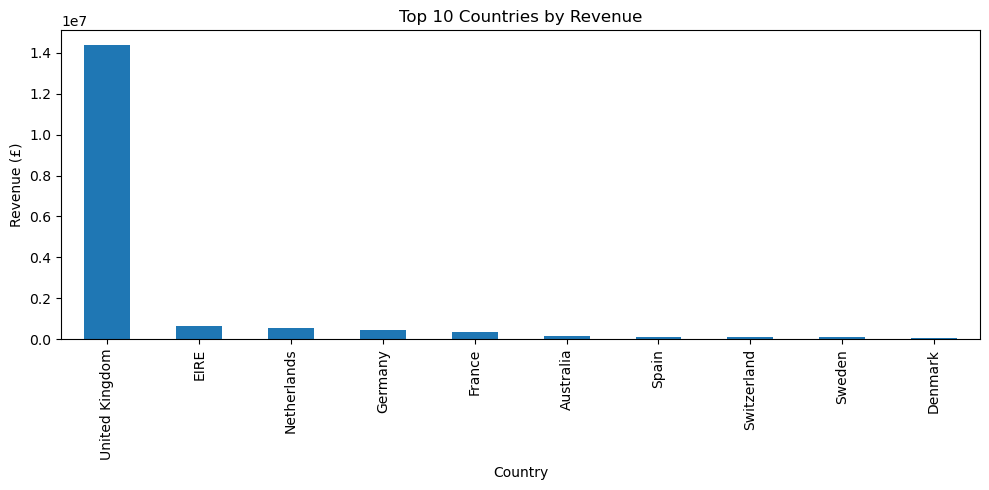

In [41]:
## Overall Revenue by Country
import matplotlib.pyplot as plt
country_revenue.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue (£)")
plt.xlabel("Country")
plt.tight_layout()
plt.show()

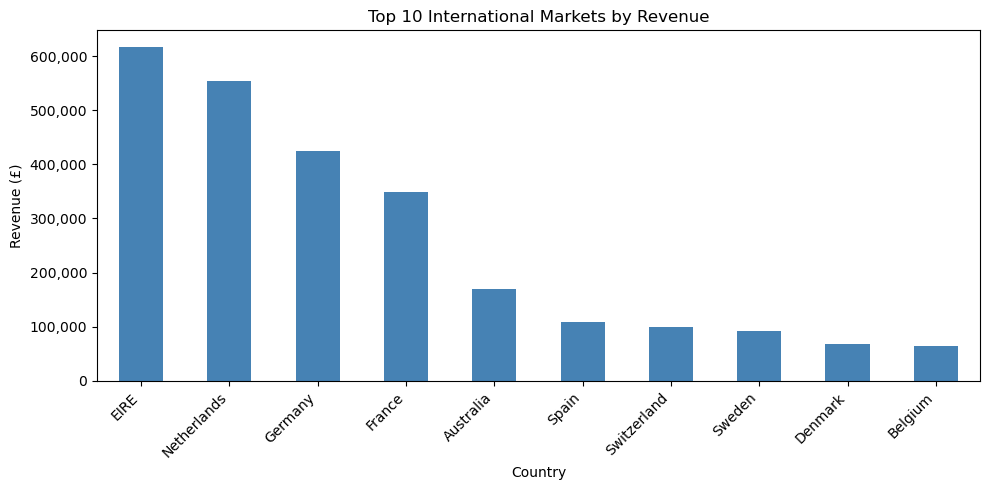

In [43]:
## Top International Markets (excluding the UK)
from matplotlib.ticker import StrMethodFormatter

ax = country_revenue_no_uk.head(10).plot(
    kind="bar",
    figsize=(10,5),
    color="steelblue"
)
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.title("Top 10 International Markets by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Insight
After excluding the United Kingdom, **EIRE (Ireland)** generated the highest international revenue, followed by the **Netherlands**, **Germany**, and **France**.
Revenue declines noticeably after the top four markets, suggesting that the retailer's international sales are concentrated in a small number of European countries. This may indicate opportunities to strengthen marketing and distribution in other regions.

### Q.3: Which products generated the most revenue?

In [44]:
# Calculate product revenue
product_revenue = (
    df_clean
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
product_revenue.head(10)

Description
REGENCY CAKESTAND 3 TIER             277,656.25
WHITE HANGING HEART T-LIGHT HOLDER   247,048.01
PAPER CRAFT , LITTLE BIRDIE          168,469.60
Manual                               151,777.67
JUMBO BAG RED RETROSPOT              134,307.44
POSTAGE                              124,648.04
ASSORTED COLOUR BIRD ORNAMENT        124,351.86
PARTY BUNTING                        103,283.38
MEDIUM CERAMIC TOP STORAGE JAR        81,416.73
PAPER CHAIN KIT 50'S CHRISTMAS        76,598.18
Name: Revenue, dtype: float64

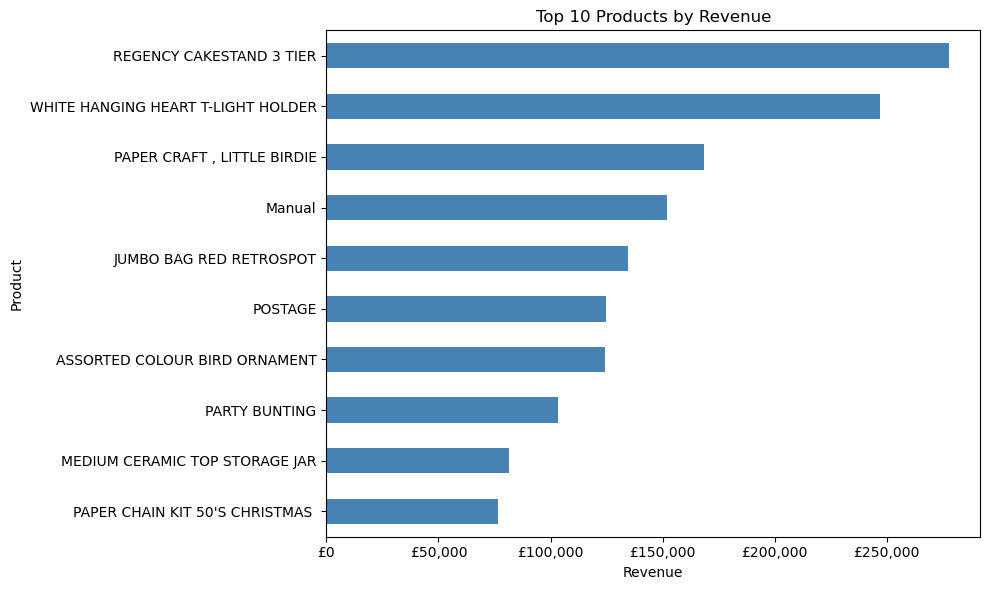

In [45]:
# Horizontal Bar Chart
from matplotlib.ticker import StrMethodFormatter
ax = (
    product_revenue
    .head(10)
    .sort_values()
    .plot(
        kind="barh",
        figsize=(10,6),
        color="steelblue"
    )
)
ax.xaxis.set_major_formatter(StrMethodFormatter("£{x:,.0f}"))
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

#### Curiosity
I know: Revenue = Quantity × Price, so the a product can rank in the top 10 because:
- It sells a huge number of units (high quantity).
- It has a high selling price.
- It has both.

In [46]:
# Compare the top revenue products
product_summary = (
    df_clean
    .groupby("Description")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Avg_Price=("Price", "mean")
    )
)
product_summary = product_summary.sort_values(
    "Total_Revenue",
    ascending=False
)
product_summary.head(10)

,Total_Revenue,Total_Quantity,Avg_Price
Description,,,
REGENCY CAKESTAND 3 TIER,"277,656.25",24124,12.46
WHITE HANGING HEART T-LIGHT HOLDER,"247,048.01",91757,2.87
"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,2.08
Manual,"151,777.67",9384,214.79
JUMBO BAG RED RETROSPOT,"134,307.44",74224,1.97
POSTAGE,"124,648.04",5235,29.94
ASSORTED COLOUR BIRD ORNAMENT,"124,351.86",78234,1.68
PARTY BUNTING,"103,283.38",23460,4.77
MEDIUM CERAMIC TOP STORAGE JAR,"81,416.73",77916,1.22


### Key Insights: 
1. High-volume bestsellers
These products aren't expensive, but customers buy lots of them.
WHITE HANGING HEART T-LIGHT HOLDER
PAPER CRAFT, LITTLE BIRDIE
JUMBO BAG RED RETROSPOT
ASSORTED COLOUR BIRD ORNAMENT
MEDIUM CERAMIC TOP STORAGE JAR
-> These are probably the retailer's core products.

2. Premium products
These generate lots of revenue because they're much more expensive.
REGENCY CAKESTAND 3 TIER
Manual
POSTAGE
-> Manual has an average price of £214.79, which is a huge outlier

=> What exactly is "Manual"?

3. Mixed performers
Products like PARTY BUNTING perform well because they have both a reasonable price and decent sales volume.

In [47]:
## Investigate the "Manual"
df_clean[df_clean["Description"] == "Manual"].head(20)
df_clean[df_clean["Description"] == "Manual"][["Invoice","Quantity","Price","Revenue"]].describe()

,Quantity,Price,Revenue
count,681.00,681.00,681.00
mean,13.78,214.79,222.87
std,91.36,904.92,904.25
min,1.00,0.06,0.08
25%,1.00,0.65,2.10
50%,1.00,1.95,6.60
75%,4.00,15.00,30.00
max,"1,600.00","10,953.50","10,953.50"


## Observation: 
"Manual" appears to represent manually entered transactions or accounting adjustments rather than a physical product. Although it ranks among the highest revenue-generating items, this is driven by a small number of unusually high-value transactions rather than consistent product sales.

In [48]:
## Investigate the "POSTAGE"
df_clean[df_clean["Description"] == "POSTAGE"].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
89,489439,POST,POSTAGE,3,2009-12-01 09:28:00,18.00,"12,682.00",France,54.00
126,489444,POST,POSTAGE,1,2009-12-01 09:55:00,141.00,"12,636.00",USA,141.00
173,489447,POST,POSTAGE,1,2009-12-01 10:10:00,130.00,"12,362.00",Belgium,130.00
625,489526,POST,POSTAGE,6,2009-12-01 11:50:00,18.00,"12,533.00",Germany,108.00
1244,489557,POST,POSTAGE,4,2009-12-01 12:52:00,18.00,"12,490.00",France,72.00


## Observation: 
POSTAGE is a service, not a product.

In [49]:
## Run the code again (Remove the Manual and Postage")
product_revenue_only = (
    df_clean[
        ~df_clean["Description"].isin(["Manual", "POSTAGE"])
    ]
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
product_revenue_only.head(10)

Description
REGENCY CAKESTAND 3 TIER             277,656.25
WHITE HANGING HEART T-LIGHT HOLDER   247,048.01
PAPER CRAFT , LITTLE BIRDIE          168,469.60
JUMBO BAG RED RETROSPOT              134,307.44
ASSORTED COLOUR BIRD ORNAMENT        124,351.86
PARTY BUNTING                        103,283.38
MEDIUM CERAMIC TOP STORAGE JAR        81,416.73
PAPER CHAIN KIT 50'S CHRISTMAS        76,598.18
CHILLI LIGHTS                         69,084.30
JUMBO BAG STRAWBERRY                  64,127.77
Name: Revenue, dtype: float64

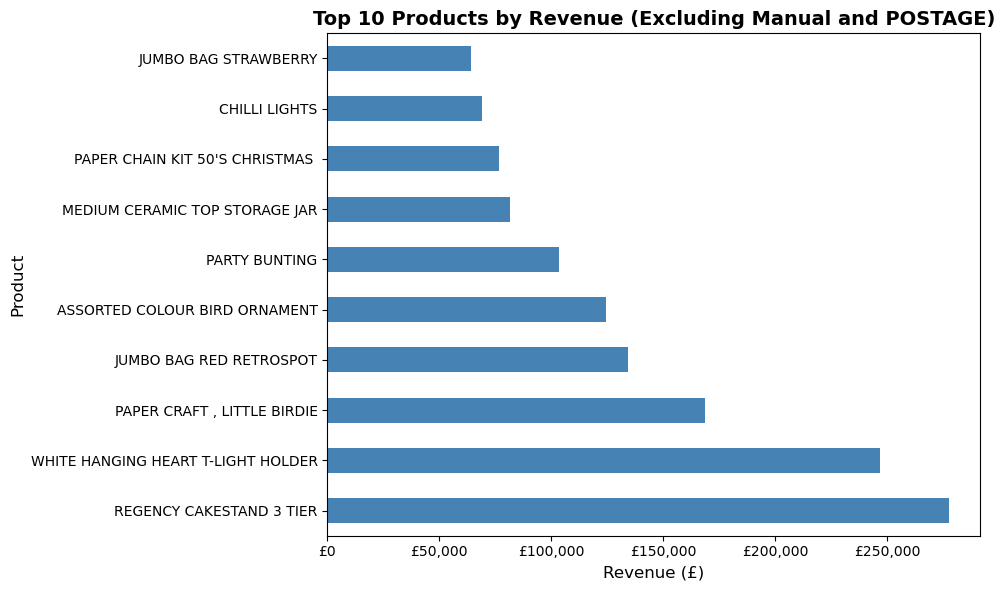

In [50]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# Top 10 products (excluding Manual and POSTAGE)
top10_products = product_revenue_only.head(10)

# Sort so the highest revenue appears at the top
top10_products = top10_products.sort_values()

# Create the chart
fig, ax = plt.subplots(figsize=(10, 6))

top10_products.plot(
    kind="barh",
    color="steelblue",
    ax=ax
)

# Format x-axis as currency
ax.xaxis.set_major_formatter(StrMethodFormatter("£{x:,.0f}"))

# Titles and labels
ax.set_title(
    "Top 10 Products by Revenue (Excluding Manual and POSTAGE)",
    fontsize=14,
    weight="bold"
)
ax.set_xlabel("Revenue (£)", fontsize=12)
ax.set_ylabel("Product", fontsize=12)

# Highest revenue at the top
ax.invert_yaxis()

plt.tight_layout()
plt.show()

### Observation
After excluding non-product entries ("Manual" and "POSTAGE"), the highest revenue-generating merchandise consists primarily of home décor and gift products.
Several top-performing products, such as WHITE HANGING HEART T-LIGHT HOLDER and JUMBO BAG RED RETROSPOT, generate high revenue through large sales volumes rather than premium pricing. In contrast, REGENCY CAKESTAND 3 TIER combines a relatively higher average selling price with strong demand, making it the company's highest revenue-generating retail product.

### Q.4: When does the business generate the most revenue?

In [51]:
### Q4.1: How has revenue changed by year?
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
revenue_by_year = (
    df_clean
    .groupby("Year")["Revenue"]
    .sum()
)
revenue_by_year

Year
2009     683,504.01
2010   8,374,496.09
2011   8,316,804.16
Name: Revenue, dtype: float64

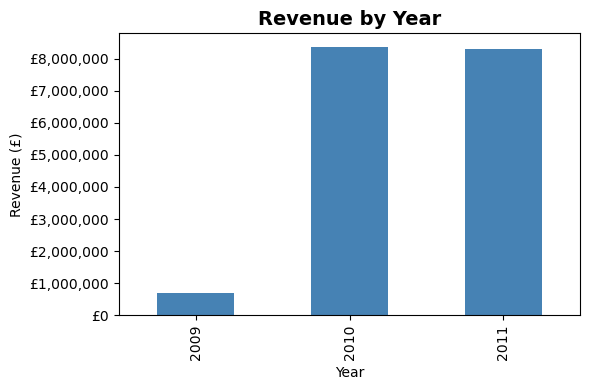

In [52]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
plt.figure(figsize=(6,4))
revenue_by_year.plot(
    kind="bar",
    color="steelblue"
)
plt.title("Revenue by Year", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Revenue (£)")
plt.gca().yaxis.set_major_formatter(StrMethodFormatter("£{x:,.0f}"))
plt.tight_layout()
plt.show()

##### Note: The dataset does not contain complete calendar years. Therefore, yearly revenue should not be interpreted as full-year business performance.

In [53]:
### Q4.2: Which months generate the most revenue?
df_clean["Month"] = df_clean["InvoiceDate"].dt.month_name()
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
revenue_by_month = (
    df_clean
    .groupby("Month")["Revenue"]
    .sum()
    .reindex(month_order)
)
revenue_by_month

Month
January     1,123,903.98
February      950,643.88
March       1,291,060.23
April       1,060,356.33
May         1,275,188.53
June        1,296,417.18
July        1,188,699.07
August      1,246,275.64
September   1,779,704.15
October     2,068,754.46
November    2,322,665.63
December    1,771,135.18
Name: Revenue, dtype: float64

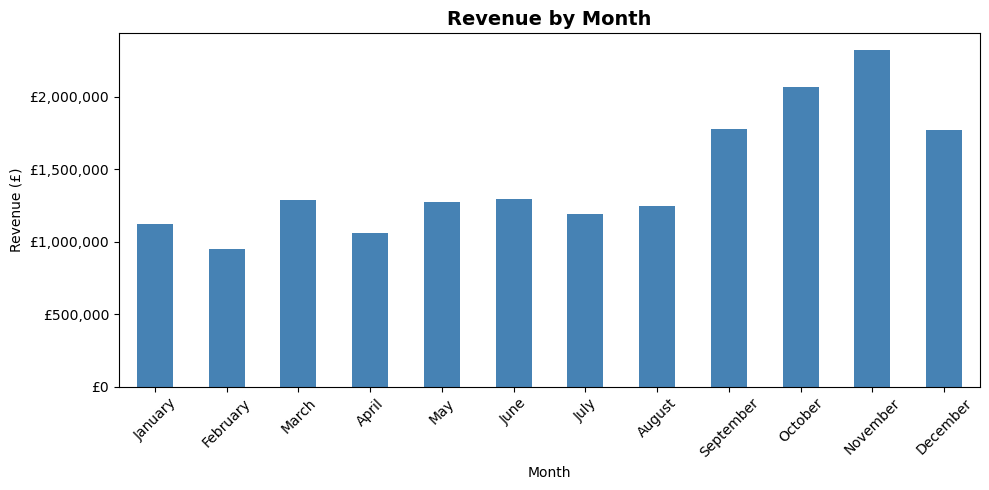

In [54]:
plt.figure(figsize=(10,5))
revenue_by_month.plot(
    kind="bar",
    color="steelblue"
)
plt.title("Revenue by Month", fontsize=14, weight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.gca().yaxis.set_major_formatter(StrMethodFormatter("£{x:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Revenue peaks during the holiday shopping season, suggesting strong seasonal demand leading up to Christmas.

In [55]:
### Q4.3: Which day of the week performs best?
df_clean["Day"] = df_clean["InvoiceDate"].dt.day_name()
day_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]
revenue_by_day = (
    df_clean
    .groupby("Day")["Revenue"]
    .sum()
    .reindex(day_order)
)
revenue_by_day

Day
Monday      2,778,201.57
Tuesday     3,322,830.14
Wednesday   3,021,043.85
Thursday    3,745,783.43
Friday      2,728,473.17
Saturday        9,803.05
Sunday      1,768,669.05
Name: Revenue, dtype: float64

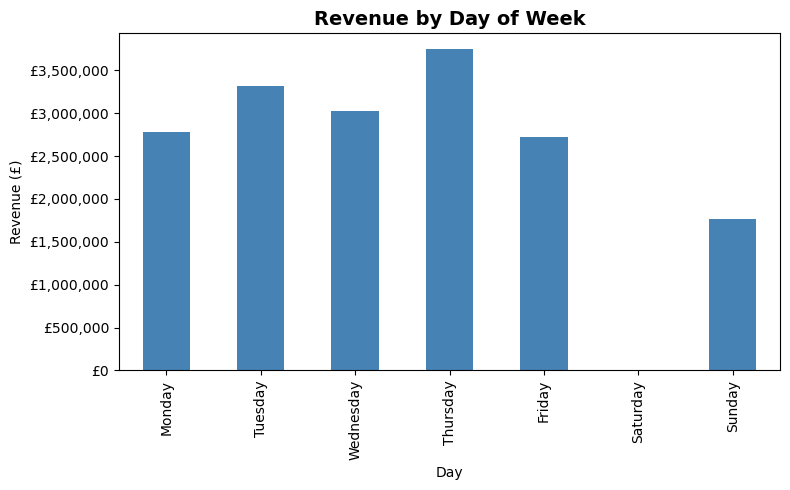

In [56]:
plt.figure(figsize=(8,5))
revenue_by_day.plot(
    kind="bar",
    color="steelblue"
)
plt.title("Revenue by Day of Week", fontsize=14, weight="bold")
plt.xlabel("Day")
plt.ylabel("Revenue (£)")
plt.gca().yaxis.set_major_formatter(StrMethodFormatter("£{x:,.0f}"))

plt.tight_layout()
plt.show()

In [ ]:
##### There are no Saturday transactions in this dataset, which may indicate the business was closed on Saturdays or that Saturday data is unavailable.

In [57]:
### Q4.4: What time of day has the highest sales?
df_clean["Hour"] = df_clean["InvoiceDate"].dt.hour
revenue_by_hour = (
    df_clean
    .groupby("Hour")["Revenue"]
    .sum()
)
revenue_by_hour

Hour
6            4.25
7       75,745.57
8      524,612.55
9    1,484,450.54
10   2,320,711.44
11   2,235,870.39
12   2,690,583.50
13   2,347,078.71
14   1,962,016.16
15   1,839,607.76
16   1,055,274.69
17     484,477.63
18     190,860.29
19     124,825.77
20      38,685.00
Name: Revenue, dtype: float64

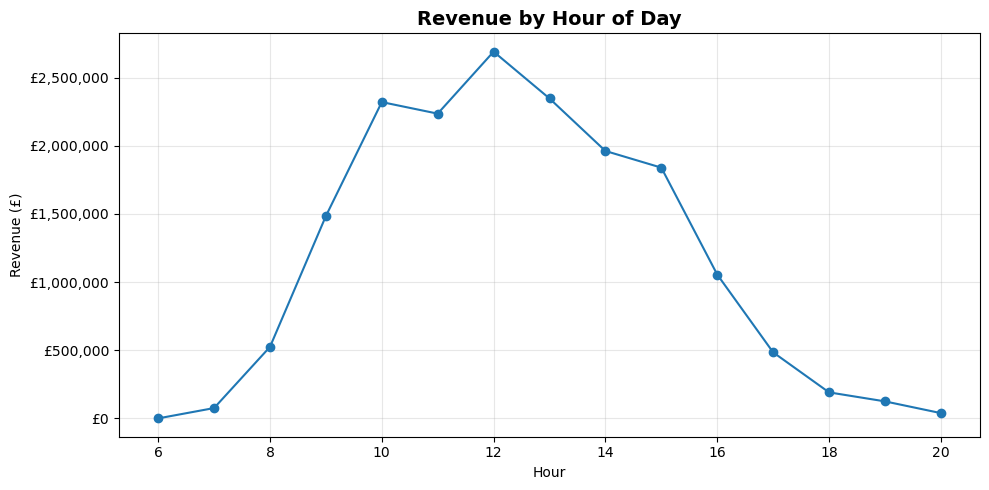

In [58]:
plt.figure(figsize=(10,5))
revenue_by_hour.plot(
    kind="line",
    marker="o"
)
plt.title("Revenue by Hour of Day", fontsize=14, weight="bold")
plt.xlabel("Hour")
plt.ylabel("Revenue (£)")
plt.gca().yaxis.set_major_formatter(StrMethodFormatter("£{x:,.0f}"))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##### Customer purchasing activity is concentrated during standard business hours, with the highest revenue generated around midday.

### Q.5: Who are the most valuable customers?

In [59]:
# Revenue by customer
customer_revenue = (
    df_clean
    .groupby("Customer ID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
customer_revenue.head(10)

Customer ID
18,102.00   580,987.04
14,646.00   528,602.52
14,156.00   313,437.62
14,911.00   291,420.81
17,450.00   244,784.25
13,694.00   195,640.69
17,511.00   172,132.87
16,446.00   168,472.50
16,684.00   147,142.77
12,415.00   144,458.37
Name: Revenue, dtype: float64

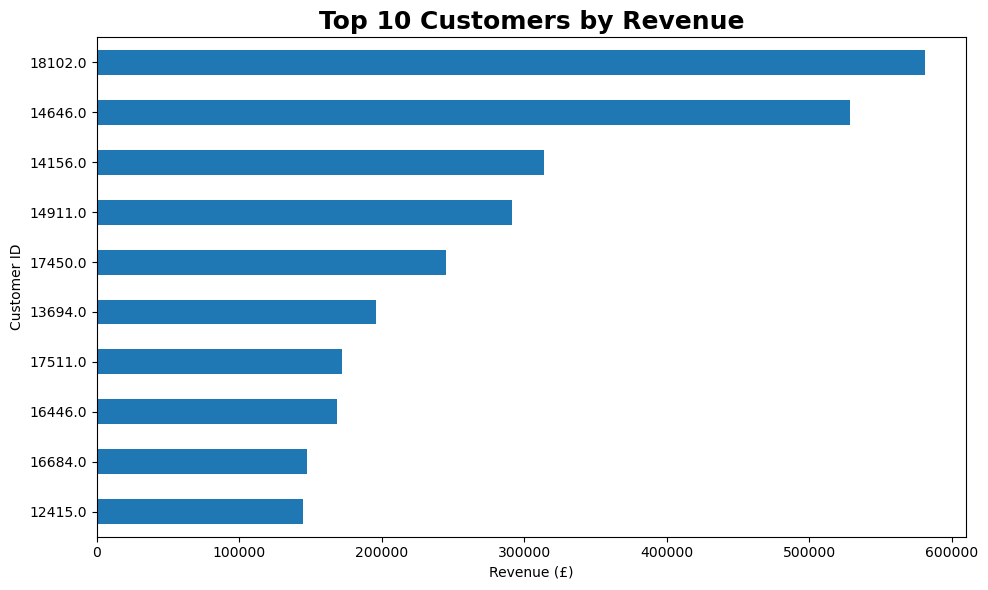

In [60]:
# Horizontal Bar Chart 
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
customer_revenue.head(10).sort_values().plot(
    kind="barh"
)
plt.title("Top 10 Customers by Revenue", fontsize=18, weight="bold")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()

In [61]:
## Additional question: How much of the company's revenue comes from these top 10 customers?
top10_revenue = customer_revenue.head(10).sum()
total_revenue = df_clean["Revenue"].sum()
top10_percentage = top10_revenue / total_revenue * 100
print(f"Top 10 Customers Revenue: £{top10_revenue:,.2f}")
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Contribution: {top10_percentage:.2f}%")

Top 10 Customers Revenue: £2,787,079.44
Total Revenue: £17,374,804.27
Contribution: 16.04%


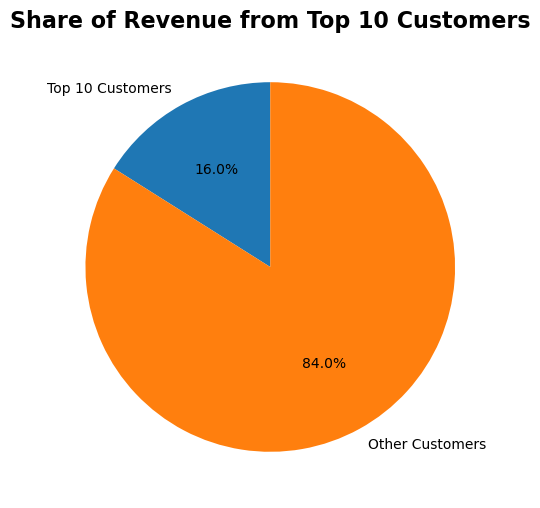

In [62]:
### Pie chart:
plt.figure(figsize=(6,6))
plt.pie(
    [top10_revenue, total_revenue - top10_revenue],
    labels=["Top 10 Customers", "Other Customers"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Share of Revenue from Top 10 Customers",
          fontsize=16,
          weight="bold")
plt.show()

In [63]:
num_customers = df_clean["Customer ID"].nunique()
print(f"Unique customers: {num_customers:,}")
print(f"Top 10 customers represent {10 / num_customers:.2%} of all customers.")
print(f"They contribute {top10_percentage:.2f}% of total revenue.")

Unique customers: 5,878
Top 10 customers represent 0.17% of all customers.
They contribute 16.04% of total revenue.


### Observation: 
The top 10 customers contributed approximately 16% of the company's total revenue, while the remaining customers generated 84%. This suggests that revenue is distributed across a broad customer base rather than being heavily dependent on a few high-value customers. Such diversification reduces the business's reliance on individual customers and may indicate a stable revenue stream.

## Conclusion

This analysis explored over 1 million retail transactions to understand sales performance, customer behavior, and revenue drivers.

### Key Findings

- The business generated approximately **£17.37 million** in revenue after data cleaning.
- The **United Kingdom** accounted for the majority of sales, with EIRE and the Netherlands as the strongest international markets.
- Products such as **REGENCY CAKESTAND 3 TIER** and **WHITE HANGING HEART T-LIGHT HOLDER** generated the highest revenue.
- Revenue peaked during **November**, indicating strong holiday-season demand.
- Sales were highest around **midday (12 PM)** and strongest on **Thursdays**.
- The top 10 customers contributed **16%** of total revenue, suggesting that while several customers are highly valuable, revenue is generated from a broad customer base.

Overall, this project demonstrates an end-to-end workflow for retail sales analysis, including data profiling, cleaning, feature engineering, exploratory data analysis, and business insight generation using Python and Pandas.